# Portfolio Face Image Generator

This notebook prepares a face-based portrait image sized to fit the about-image-wrap space in the portfolio page. It uses PIL to inspect, crop, blend, and save a result for the HTML asset.


Source exists: True
Mode: RGBA
Size: (1024, 1024)


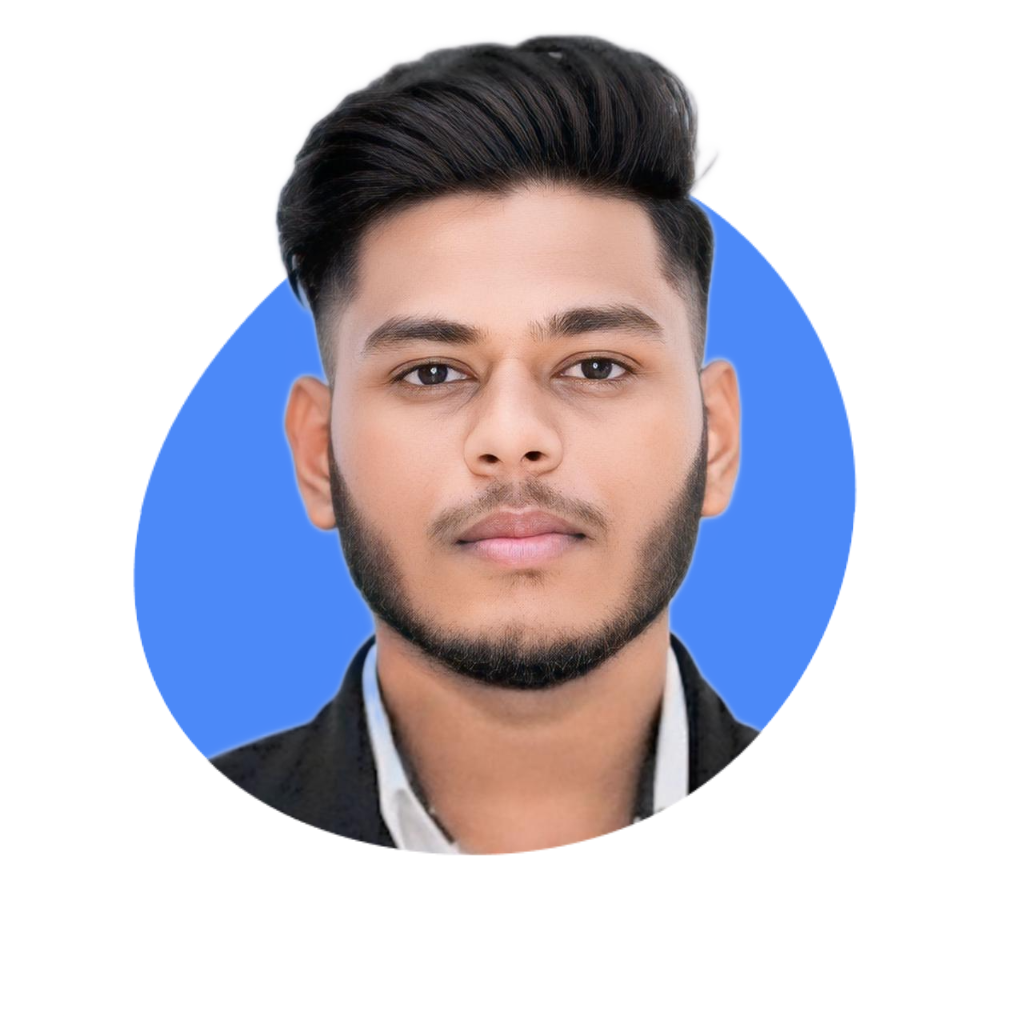

In [1]:
from pathlib import Path
from PIL import Image, ImageOps, ImageFilter

source = Path('D:/Code/Intern Model/images/profile-pic-edited.png')
print('Source exists:', source.exists())
img = Image.open(source).convert('RGBA')
print('Mode:', img.mode)
print('Size:', img.size)
img

In [2]:
from pathlib import Path
from PIL import Image

html_path = Path('D:/Code/Intern Model/Portfolio/index.html')
text = html_path.read_text(encoding='utf-8')
print('HTML file found:', html_path.exists())
for token in ['.about-img-wrap {', '.about-img-wrap img {', 'max-width: 360px', 'max-height: 500px']:
    print(token, '=>', token in text)

# Target wrapper dimensions used in the portfolio CSS.
TARGET_W = 360
TARGET_H = 420
print('Target canvas size:', (TARGET_W, TARGET_H))

HTML file found: True
.about-img-wrap { => True
.about-img-wrap img { => True
max-width: 360px => True
max-height: 500px => False
Target canvas size: (360, 420)


Background image created: (360, 420)


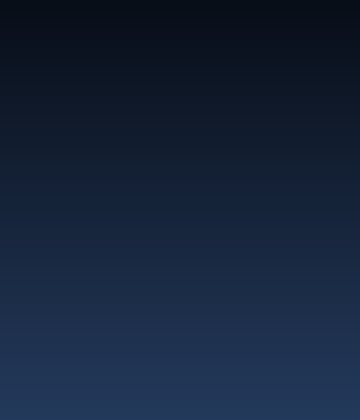

In [3]:
bg = Image.new('RGBA', (360, 420), (8, 10, 18, 255))
for y in range(420):
    t = y / 419
    r = int(8 + (36 - 8) * t)
    g = int(14 + (58 - 14) * t)
    b = int(24 + (92 - 24) * t)
    for x in range(360):
        bg.putpixel((x, y), (r, g, b, 255))

bg = bg.convert('RGB')
print('Background image created:', bg.size)
bg

Cropped face size: (260, 320)


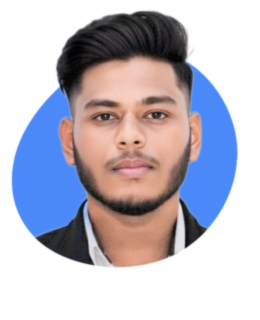

In [4]:
face = Image.open(source).convert('RGBA')
face = ImageOps.fit(face, (260, 320), method=Image.Resampling.LANCZOS)
face = face.filter(ImageFilter.GaussianBlur(0.6))
print('Cropped face size:', face.size)
face

Final canvas size: (360, 420)


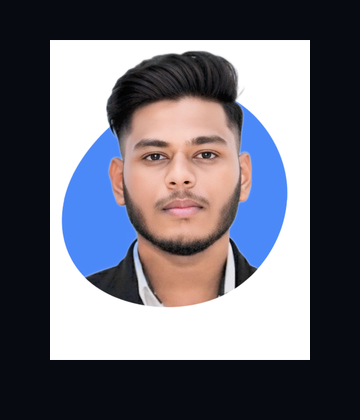

In [5]:
canvas = Image.new('RGBA', (360, 420), (8, 10, 18, 255))
face = Image.open(source).convert('RGBA')
face = ImageOps.fit(face, (260, 320), method=Image.Resampling.LANCZOS)

# Blend the face into the canvas with soft lighting and a rounded card feel.
canvas.alpha_composite(face, (50, 40))

# Add a subtle vignette and glow.
for y in range(420):
    for x in range(360):
        dx = x - 180
        dy = y - 210
        dist = (dx * dx + dy * dy) ** 0.5
        maxd = (180 * 180 + 210 * 210) ** 0.5
        alpha = int(255 * max(0.15, 1 - dist / maxd * 0.45))
        r, g, b, a = canvas.getpixel((x, y))
        canvas.putpixel((x, y), (r, g, b, alpha))

canvas = canvas.convert('RGB')
print('Final canvas size:', canvas.size)
canvas

In [6]:
output_path = Path('D:/Code/Intern Model/images/portfolio-face-fit.png')
output_path.parent.mkdir(exist_ok=True)
canvas.save(output_path, format='PNG')
print('Saved to:', output_path)
print('Exists:', output_path.exists())
output_path

Saved to: D:\Code\Intern Model\images\portfolio-face-fit.png
Exists: True


WindowsPath('D:/Code/Intern Model/images/portfolio-face-fit.png')

In [ ]:
from IPython.display import Image as DisplayImage
DisplayImage(filename='D:/Code/Intern Model/images/portfolio-face-fit.png', width=360)

In [ ]:
# Optional: use this image in the portfolio by updating the HTML src to the generated file.
output_path = Path('D:/Code/Intern Model/images/portfolio-face-fit.png')
print('Use this path in the portfolio HTML:', output_path.relative_to('D:/Code/Intern Model'))